# ResNet-50 (Partial Unfreeze — layer4 only)

## Changes from Frozen Baseline

| | 01. Frozen Baseline | 02. Partial Unfreeze |
|---|---|---|
| Backbone | Fully frozen | `layer4` unfrozen, layers 1–3 frozen |
| Trainable params | ~2K (FC only) | ~15M (layer4 + FC) |
| LR — FC head | 1e-3 | 1e-3 |
| LR — layer4 | — | 1e-4 (10x lower) |
| Dropout | 0.5 | 0.5 |
| Epochs | 20 | 30 |

## Rationale

The frozen baseline achieved test F2 **0.5469** and AUC-ROC **0.8290**. The AUC tells us ResNet-50's ImageNet features can rank melanoma vs non-melanoma reasonably well — the bottleneck is that the features are not adapted to dermoscopy images.

`layer4` in ResNet-50 encodes the highest-level semantic representations (the most task-specific part of the network). Unfreezing it allows these features to shift toward dermoscopy-relevant patterns, while keeping layers 1–3 frozen preserves low-level edge/texture features that transfer well from ImageNet.

**Layer-wise learning rates** are critical here. Using the same LR for `layer4` as for the FC head risks catastrophic forgetting — the pretrained weights get overwritten too fast. A 10x lower LR on `layer4` (1e-4 vs 1e-3) lets it adapt gradually without destroying what ImageNet pretraining gave us.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
    transform_train=get_augmented_train_transforms(image_size=224),
)

# Rebuild train loader with persistent_workers
from src.data.dataset import HAM10000Dataset
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

train_df = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
# Start from a frozen backbone, then selectively unfreeze layer4
model = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.5).to(device)

for param in model.layer4.parameters():
    param.requires_grad = True

# Layer-wise LR: lower for pretrained layer4, higher for the new FC head
optimizer = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 14,966,785 / 23,510,081


In [6]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_partial_unfreeze_best.pth')
        print(f'  -> Saved best model (val F2: {best_val_f2:.4f})')

Epoch [1/30] | Train Loss: 0.9436, Bal Acc: 0.7106, Recall: 0.7674, F2: 0.5065 | Val Loss: 0.8220, Bal Acc: 0.7607, Recall: 0.8771, F2: 0.5792
  -> Saved best model (val F2: 0.5792)


Epoch [2/30] | Train Loss: 0.7877, Bal Acc: 0.7877, Recall: 0.8347, F2: 0.6016 | Val Loss: 0.7968, Bal Acc: 0.7808, Recall: 0.8771, F2: 0.6035
  -> Saved best model (val F2: 0.6035)


Epoch [3/30] | Train Loss: 0.7277, Bal Acc: 0.8136, Recall: 0.8620, F2: 0.6369 | Val Loss: 0.8251, Bal Acc: 0.7982, Recall: 0.7373, F2: 0.6350
  -> Saved best model (val F2: 0.6350)


Epoch [4/30] | Train Loss: 0.6881, Bal Acc: 0.8213, Recall: 0.8426, F2: 0.6517 | Val Loss: 0.7796, Bal Acc: 0.8128, Recall: 0.8136, F2: 0.6522
  -> Saved best model (val F2: 0.6522)


Epoch [5/30] | Train Loss: 0.6537, Bal Acc: 0.8373, Recall: 0.8632, F2: 0.6750 | Val Loss: 0.8063, Bal Acc: 0.7921, Recall: 0.7754, F2: 0.6229


...

Epoch [26/30] | Train Loss: 0.2849, Bal Acc: 0.9384, Recall: 0.9578, F2: 0.8528 | Val Loss: 1.4602, Bal Acc: 0.7831, Recall: 0.6864, F2: 0.6132


Epoch [27/30] | Train Loss: 0.2653, Bal Acc: 0.9405, Recall: 0.9578, F2: 0.8582 | Val Loss: 1.4236, Bal Acc: 0.7828, Recall: 0.6864, F2: 0.6127


Epoch [28/30] | Train Loss: 0.2754, Bal Acc: 0.9392, Recall: 0.9532, F2: 0.8571 | Val Loss: 1.4416, Bal Acc: 0.7806, Recall: 0.6864, F2: 0.6090


Epoch [29/30] | Train Loss: 0.2976, Bal Acc: 0.9330, Recall: 0.9430, F2: 0.8470 | Val Loss: 1.4940, Bal Acc: 0.7862, Recall: 0.6864, F2: 0.6183


Epoch [30/30] | Train Loss: 0.2709, Bal Acc: 0.9392, Recall: 0.9532, F2: 0.8571 | Val Loss: 1.5310, Bal Acc: 0.7851, Recall: 0.6864, F2: 0.6164


## Training Curves

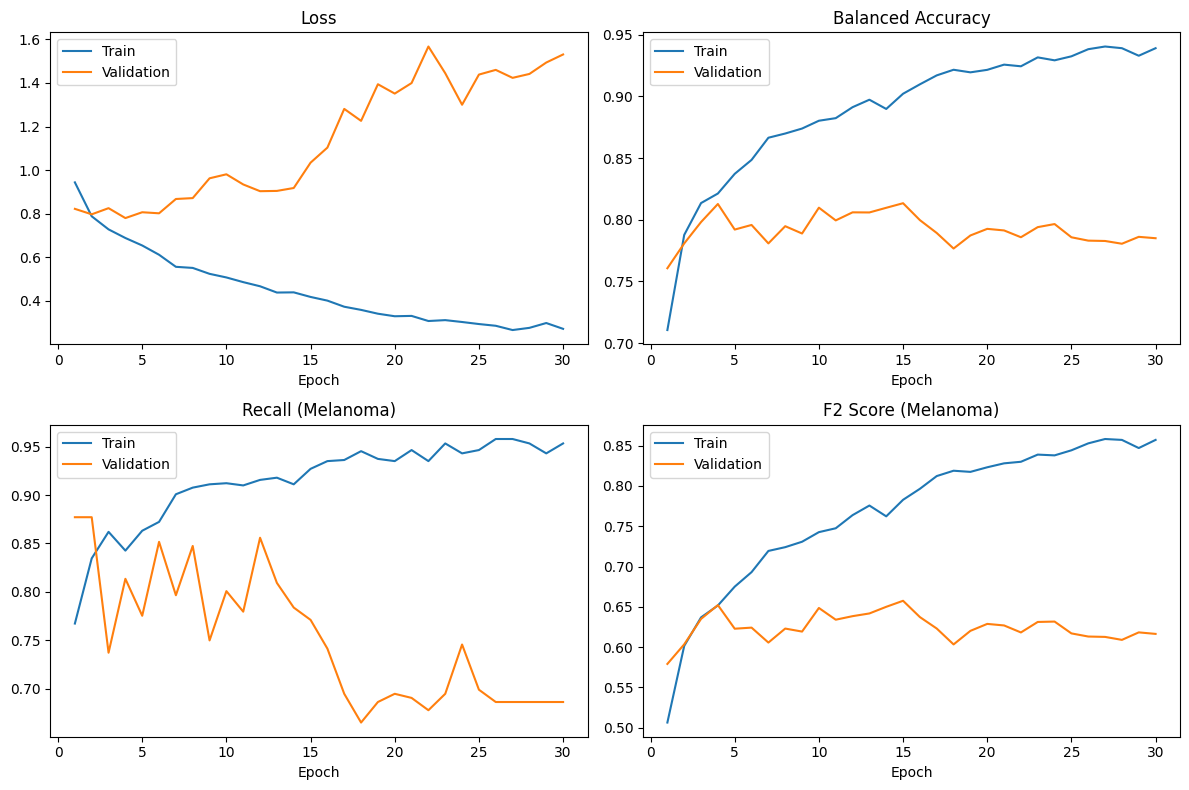

In [7]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [8]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_partial_unfreeze_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.53 | Val F2: 0.6625


## Test Set Evaluation

Threshold:          0.53
AUC-ROC:            0.8804
Balanced Accuracy:  0.7677
F2 Score:           0.5852

              precision    recall  f1-score   support

Non-Melanoma     0.9533    0.8687    0.9090      1340
    Melanoma     0.3931    0.6667    0.4946       171

    accuracy                         0.8458      1511
   macro avg     0.6732    0.7677    0.7018      1511
weighted avg     0.8899    0.8458    0.8621      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


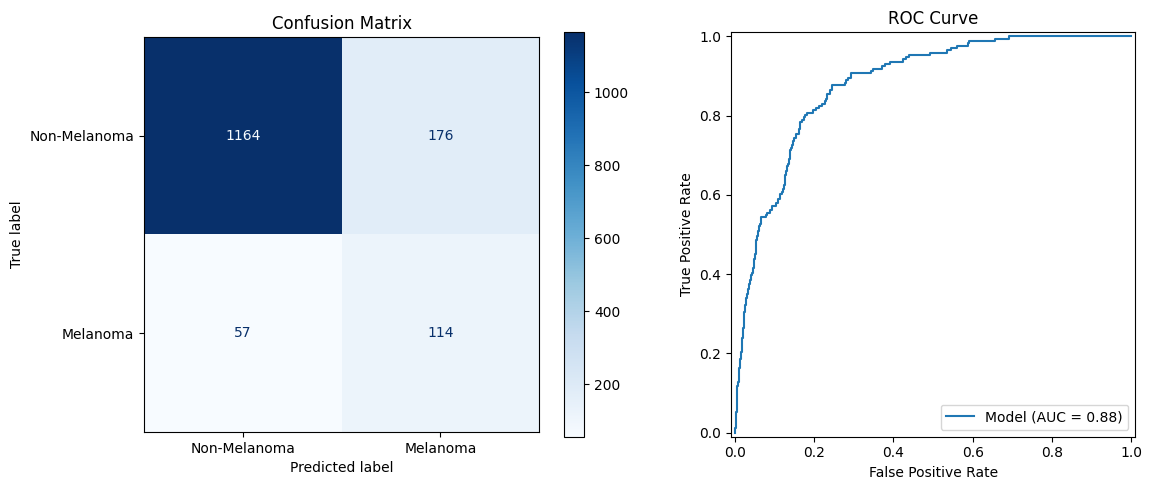

In [9]:
evaluate_model(model, test_loader, device, threshold=best_threshold)